In [1]:
import mrcfile
import torch
import matplotlib.pyplot as plt
import numpy as np

from torch_fourier_slice.slice_extraction._extract_central_slices_rfft_3d import (
    extract_central_slices_rfft_3d,
)
from pathlib import Path

In [2]:
def compare_slices(ground_truth_FS, angles, reconstructed_FSs: list, plots: bool = True):
    """
    Compare the slices of the ground truth FS with the reconstructed FSs.

    Parameters
    ----------
    ground_truth_FS : np.ndarray
        The ground truth FS.
    angles : list
        The angles of the slices.
    reconstructed_FSs : list
        A list of reconstructed FSs.
    plots : bool, optional
        Whether to plot the comparison of the slices.

    Returns
    -------
    If plots is True, it will plot the comparison of the slices.
        Plots the comparison of the slices.
    Elsewhise, it will return a score of differences between the ground truth FS and the reconstructed FSs.
    """

    return None

def compute_power_spectrum(data: np.ndarray) -> np.ndarray:
    ft = np.fft.fftshift(np.fft.fftn(data))
    return np.log(np.abs(ft) + 1e-8)  # small epsilon to avoid log(0)

def shape_into_cubic(volume):
    """
    Reshape a 3D volume into a cubic shape by removing values
    (center-crop each dimension down to the size of the smallest one).

    Parameters
    ----------
    volume : torch.Tensor
        The 3D volume to reshape.

    Returns
    -------
    torch.Tensor
        The reshaped cubic volume.
    """
    min_dim = min(volume.shape)
    slices = []
    for dim in volume.shape:
        start = dim // 2 - min_dim // 2
        end = start + min_dim
        slices.append(slice(start, end))
    return volume[tuple(slices)]

In [3]:
def plot_slice(data, axis=0, index=None, threshold=None, percentile=95):
    """
    Plot a 2D slice of a 3D field along the specified axis.
    If index is None, the middle slice is plotted.
    If threshold is None, it's set automatically using `percentile`
    (e.g. top 5% of intensity values).
    """
    if index is None:
        index = data.shape[axis] // 2

    if threshold is None:
        threshold = np.percentile(data, percentile)

    if axis == 0:
        slice_data = data[index, :, :]
    elif axis == 1:
        slice_data = data[:, index, :]
    elif axis == 2:
        slice_data = data[:, :, index]
    else:
        raise ValueError("Axis must be 0, 1, or 2.")

    plt.figure()
    plt.imshow(slice_data.T, origin='lower', cmap='gray', vmin=0, vmax=np.max(slice_data))
    plt.colorbar(label='Intensity')
    plt.title(f'Slice along axis {axis} at index {index} (threshold={threshold:.3f})')
    plt.xlabel('X-axis' if axis != 0 else 'Y-axis')
    plt.ylabel('Y-axis' if axis != 1 else 'Z-axis')
    plt.show()

def plot_image(data, title='Image', cmap='gray', vmin=None, vmax=None):
    plt.figure()
    plt.imshow(data, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar(label='Intensity')
    plt.title(title)
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.show()


In [4]:
### Import the mrc files

base_path = Path("C:/Users/ruben/OneDrive - Delft University of Technology/Documenten/Nanobiology 6/ARP/tomo108/")

ground_truth = base_path / "gt_tomo200528_108_10.00Apx.mrc"
fbp_truth = base_path / "tomo200528_108_10.00Apx.mrc"
icecream_truth = base_path / "tomo200528_108_10.00Apx_tomo200528_108_10.00Apx_icecream.mrc"
ddw_truth = base_path / "tomo200528_108_10.00Apx+tomo200528_108_10.00Apx_ddw_refined.mrc"

with mrcfile.open(ground_truth) as mrc:
    ground_truth_data = torch.tensor(mrc.data, dtype=torch.float32)
    ground_truth_data_PS = compute_power_spectrum(ground_truth_data.numpy())
    box_ground_truth_data = shape_into_cubic(ground_truth_data)
    box_ground_truth_data_PS = compute_power_spectrum(box_ground_truth_data.numpy())

with mrcfile.open(fbp_truth) as mrc:
    fbp_truth_data = torch.tensor(mrc.data, dtype=torch.float32)
    fbp_truth_data_PS = compute_power_spectrum(fbp_truth_data.numpy())
    box_fbp_truth_data = shape_into_cubic(fbp_truth_data)
    box_fbp_truth_data_PS = compute_power_spectrum(box_fbp_truth_data.numpy())

with mrcfile.open(icecream_truth) as mrc:
    icecream_truth_data = torch.tensor(mrc.data, dtype=torch.float32)
    icecream_truth_data_PS = compute_power_spectrum(icecream_truth_data.numpy())
    box_icecream_truth_data = shape_into_cubic(icecream_truth_data)
    box_icecream_truth_data_PS = compute_power_spectrum(box_icecream_truth_data)

with mrcfile.open(ddw_truth) as mrc:
    ddw_truth_data = torch.tensor(mrc.data, dtype=torch.float32)
    ddw_truth_data_PS = compute_power_spectrum(ddw_truth_data.numpy())
    box_ddw_truth_data = shape_into_cubic(ddw_truth_data)
    box_ddw_truth_data_PS = compute_power_spectrum(box_ddw_truth_data.numpy())

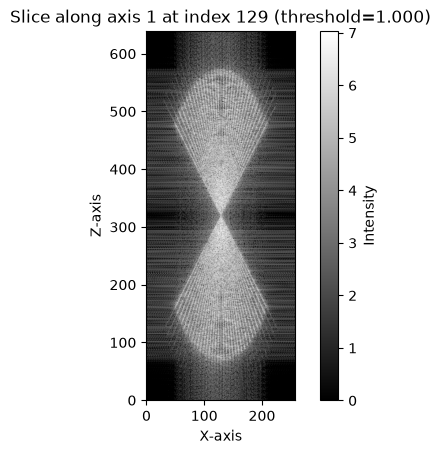

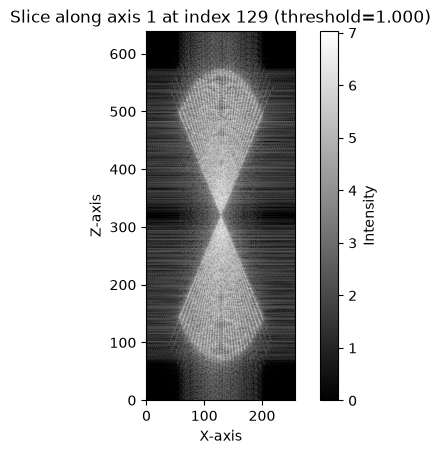

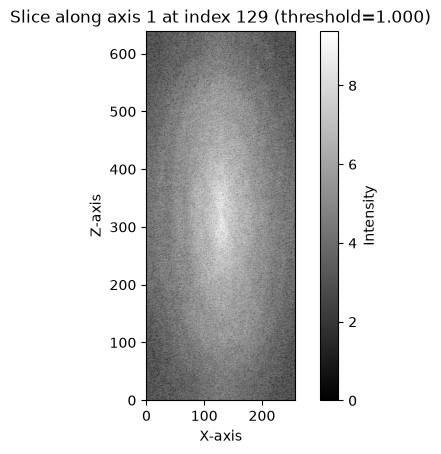

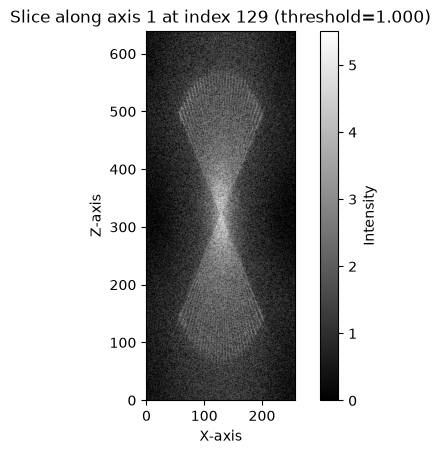

In [5]:
plot_slice(ground_truth_data_PS, axis=1, index=ground_truth_data.shape[0]//2, threshold=1, percentile=95)
plot_slice(fbp_truth_data_PS, axis=1, index=fbp_truth_data.shape[0]//2, threshold=1, percentile=95)
plot_slice(icecream_truth_data_PS, axis=1, index=icecream_truth_data.shape[0]//2, threshold=1, percentile=95)
plot_slice(ddw_truth_data_PS, axis=1, index=ddw_truth_data.shape[0]//2, threshold=1, percentile=95)


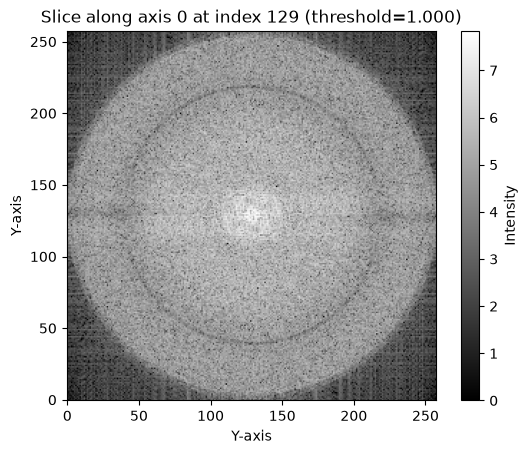

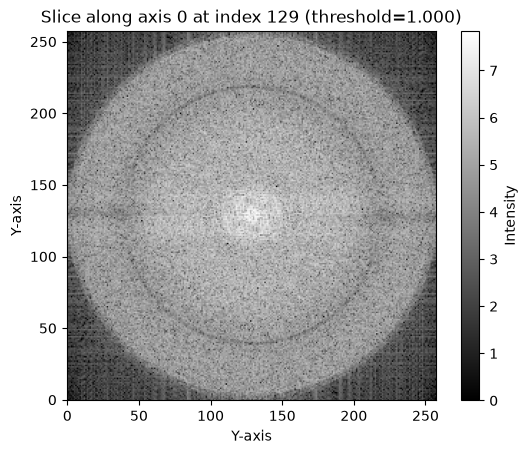

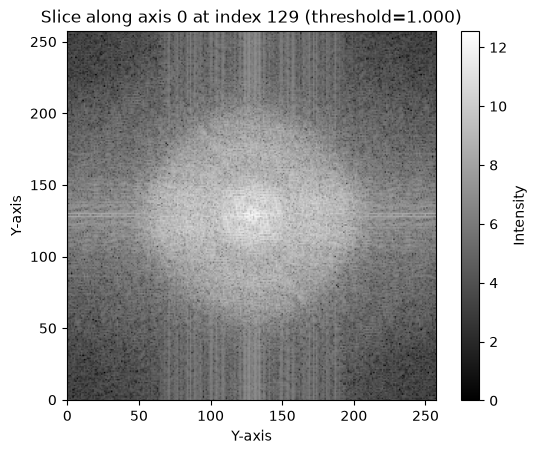

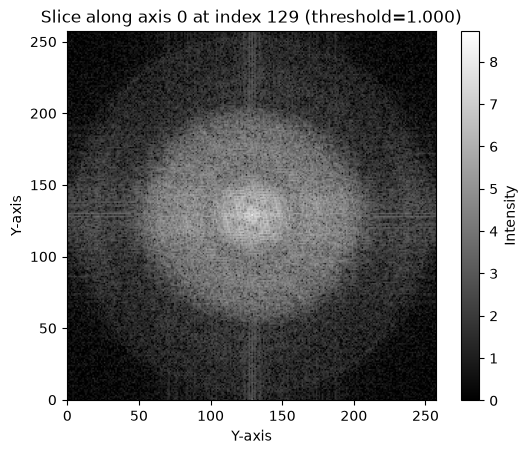

In [6]:
plot_slice(box_ground_truth_data_PS, axis=0, index=ground_truth_data.shape[0]//2, threshold=1, percentile=95)
plot_slice(box_fbp_truth_data_PS, axis=0, index=fbp_truth_data.shape[0]//2, threshold=1, percentile=95)
plot_slice(box_icecream_truth_data_PS, axis=0, index=icecream_truth_data.shape[0]//2, threshold=1, percentile=95)
plot_slice(box_ddw_truth_data_PS, axis=0, index=ddw_truth_data.shape[0]//2, threshold=1, percentile=95)


In [7]:
def rotation_matrix_y(angle_deg, device="cpu"):
    theta = torch.deg2rad(torch.tensor(float(angle_deg), device=device))
    c, s = torch.cos(theta), torch.sin(theta)
    return torch.stack([
        torch.stack([ c, torch.tensor(0.0, device=device),  s]),
        torch.stack([ torch.tensor(0.0, device=device), torch.tensor(1.0, device=device), torch.tensor(0.0, device=device)]),
        torch.stack([-s, torch.tensor(0.0, device=device),  c]),
    ])

def extract_slices(volume, angles):
    """
    Extract slices from a 3D volume at specified angles.

    Parameters
    ----------
    volume : torch.Tensor
        The 3D volume from which to extract slices.
    angles : list
        A list of angles (in degrees) at which to extract slices.

    Returns
    -------
    torch.Tensor
        A tensor containing the extracted slices.
    """

    rotation_matrices = torch.stack([rotation_matrix_y(a) for a in angles])

    return extract_central_slices_rfft_3d(volume, rotation_matrices)

In [8]:
def create_fft(volume):
    # volume center to array origin

    dft = torch.fft.ifftshift(volume, dim=(-3, -2, -1))

    dft = torch.fft.rfftn(dft, dim=(-3, -2, -1))

    # fftshift the transformed volume so DC is at center

    dft = torch.fft.fftshift(dft, dim=(-3, -2))

    return dft

In [9]:
angles = [51.0, 48.0, -47.99, -50.99]
# angles = np.arange(-51, 54, 3)

images_ground_truth = extract_slices(create_fft(box_ground_truth_data), angles)
images_fbp = extract_slices(create_fft(box_fbp_truth_data), angles)
images_icecream = extract_slices(create_fft(box_icecream_truth_data), angles)
images_ddw = extract_slices(create_fft(box_ddw_truth_data), angles)

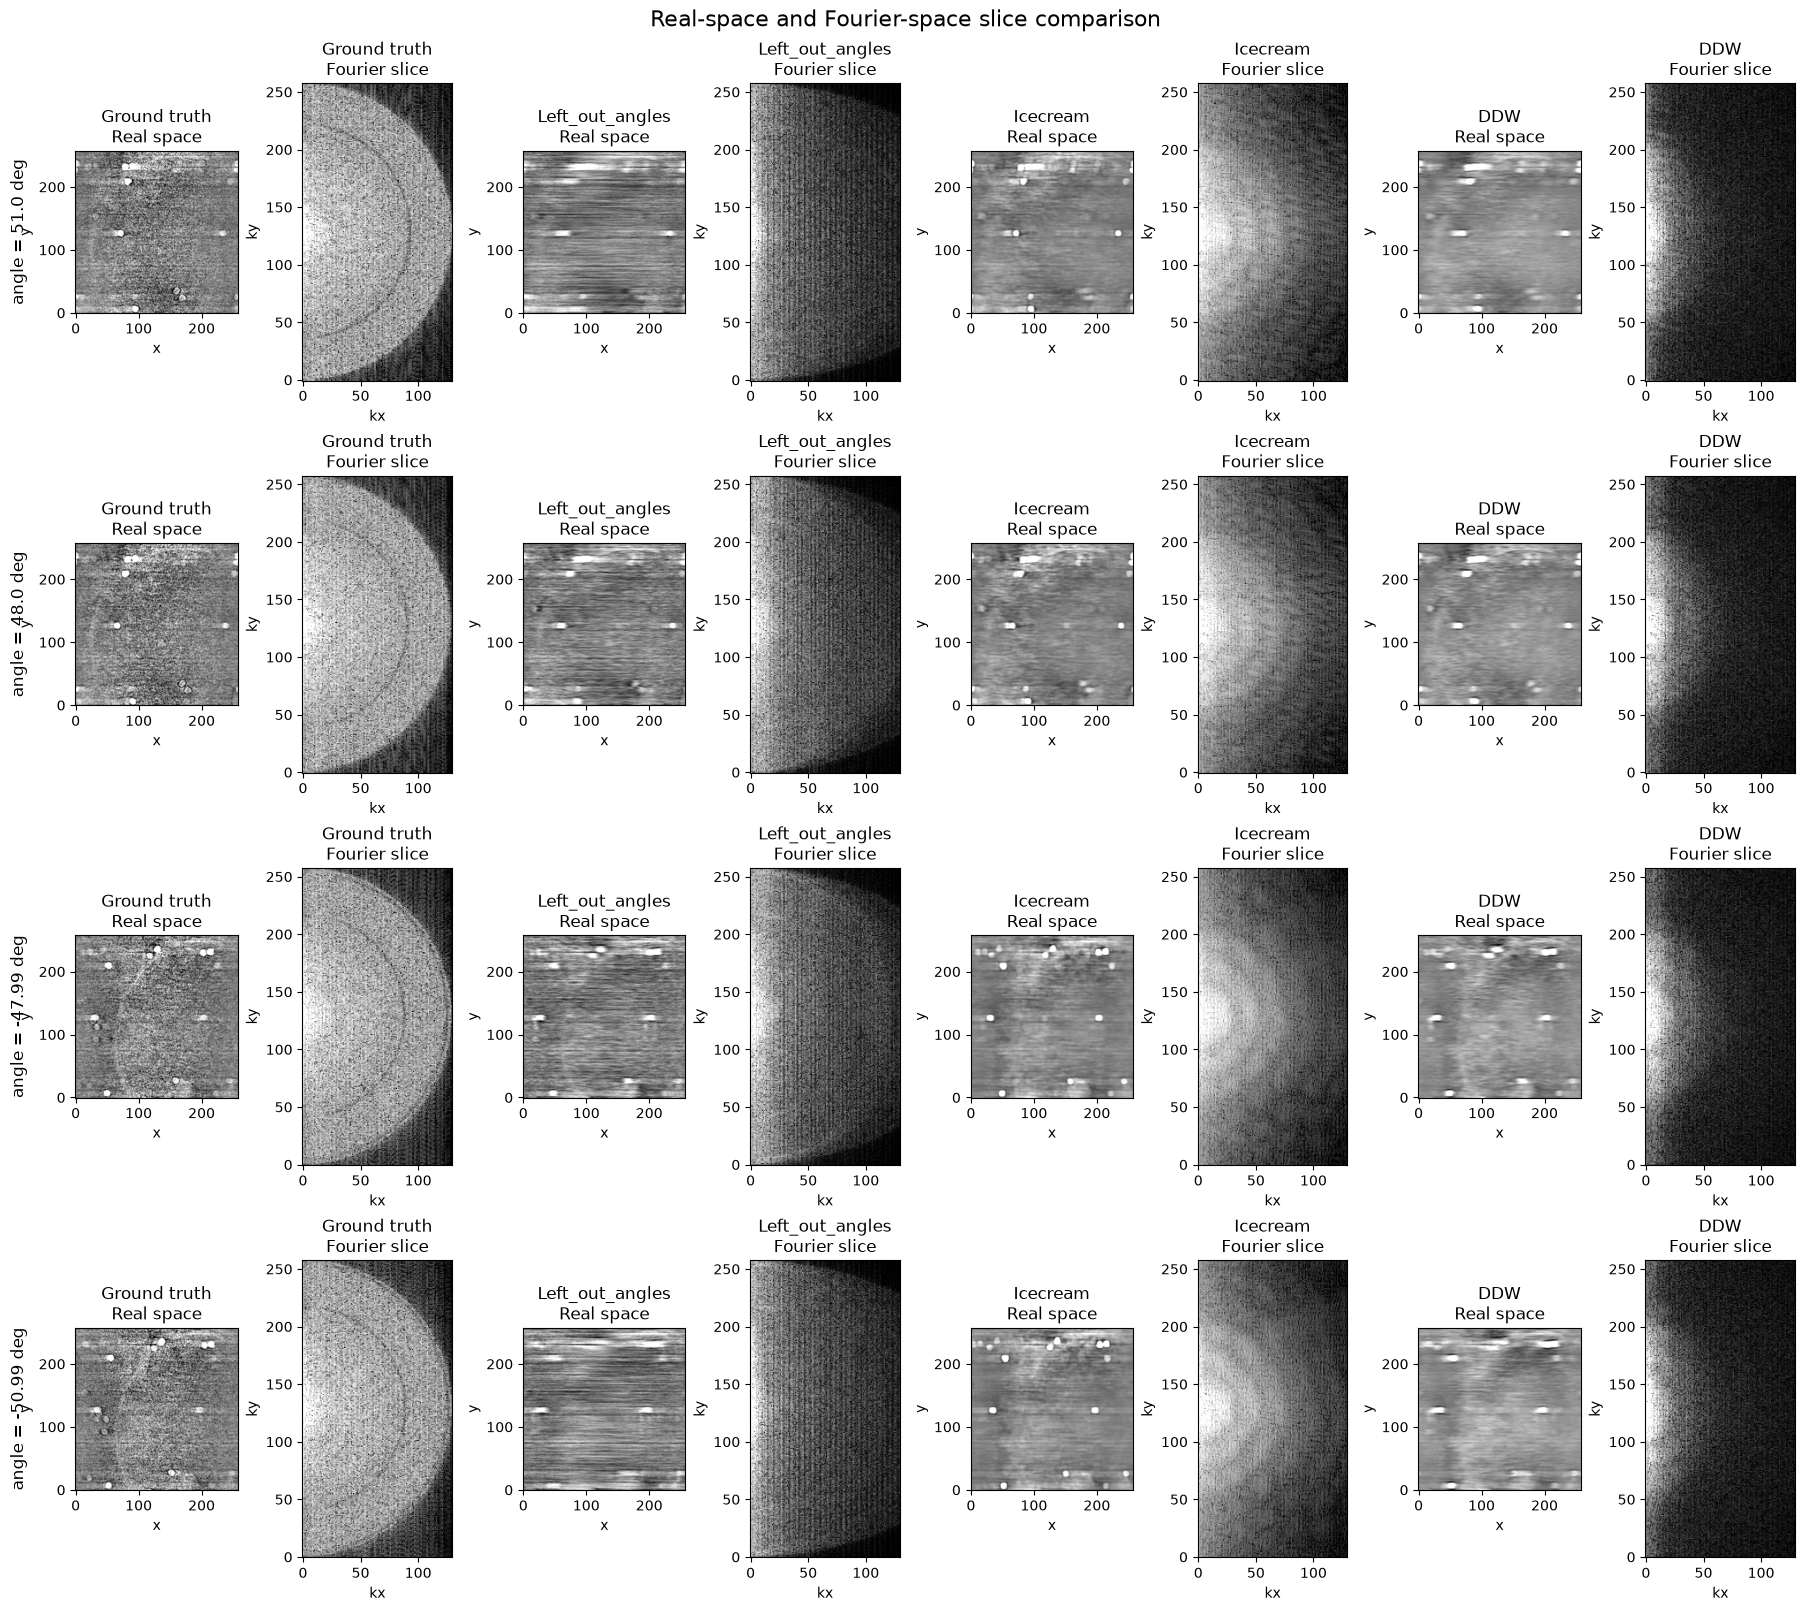

In [10]:
def fourier_slice_to_real_space(fourier_slice):
    """Invert one slice stored in the rFFT convention of create_fft."""
    fourier_slice = fourier_slice.detach().cpu()
    spatial_size = 2 * (fourier_slice.shape[-1] - 1)
    unshifted_slice = torch.fft.ifftshift(fourier_slice, dim=(-2,))
    real_space = torch.fft.irfft2(
        unshifted_slice,
        s=(spatial_size, spatial_size),
        dim=(-2, -1),
    )
    return torch.fft.fftshift(real_space, dim=(-2, -1)).numpy()


volume_names = ["Ground truth", "Left_out_angles", "Icecream", "DDW"]
volume_slices = [images_ground_truth, images_fbp, images_icecream, images_ddw]

if any(len(volume) != len(angles) for volume in volume_slices):
    raise ValueError("Run the angle and extraction cell before running this comparison cell.")

real_bool = True
fourier_bool = True

if not real_bool and not fourier_bool:
    raise ValueError("At least one of real_bool or fourier_bool must be True.")

plots_per_volume = int(real_bool) + int(fourier_bool)
fig, axes = plt.subplots(
    nrows=len(angles),
    ncols=plots_per_volume * len(volume_slices),
    figsize=(18, 4 * len(angles)),
    constrained_layout=True,
    squeeze=False,
)

for angle_index, angle in enumerate(angles):
    real_space_slices = [
        fourier_slice_to_real_space(volume[angle_index])
        for volume in volume_slices
    ]
    fourier_space_slices = [
        np.log1p(np.abs(volume[angle_index].detach().cpu().numpy()))
        for volume in volume_slices
    ]

    plot_index = 0
    for volume_index, volume_name in enumerate(volume_names):
        real_space_slice = real_space_slices[volume_index]
        fourier_space_slice = fourier_space_slices[volume_index]

        if real_bool:
            real_axis = axes[angle_index, plot_index]
            real_limit = np.percentile(np.abs(real_space_slice), 99)
            real_axis.imshow(
                real_space_slice,
                cmap="gray",
                origin="lower",
                vmin=-real_limit,
                vmax=real_limit,
            )
            real_axis.set_title(f"{volume_name}\nReal space")
            real_axis.set_xlabel("x")
            real_axis.set_ylabel("y")
            plot_index += 1

        if fourier_bool:
            fourier_axis = axes[angle_index, plot_index]
            fourier_limits = (
                np.percentile(fourier_space_slice, 1),
                np.percentile(fourier_space_slice, 99),
            )
            fourier_axis.imshow(
                fourier_space_slice,
                cmap="grey",
                origin="lower",
                vmin=fourier_limits[0],
                vmax=fourier_limits[1],
            )
            fourier_axis.set_title(f"{volume_name}\nFourier slice")
            fourier_axis.set_xlabel("kx")
            fourier_axis.set_ylabel("ky")
            plot_index += 1

    axes[angle_index, 0].annotate(
        f"angle = {angle} deg",
        xy=(-0.35, 0.5),
        xycoords="axes fraction",
        rotation=90,
        va="center",
        ha="center",
        fontsize=12,
    )

fig.suptitle("Real-space and Fourier-space slice comparison", fontsize=16)
plt.show()


In [11]:
def plot_scores(scores, volume_names, angles):
    """
    Plot the scores of differences between the ground truth FS and the reconstructed FSs.

    Parameters
    ----------
    scores : list
        A list of scores for each reconstructed FS.
    volume_names : list
        A list of names for each reconstructed FS.

    angles : list
        A list of angles corresponding to the slices.

    Returns
    -------     
    """
    
    plt.figure()
    for score, name in zip(scores, volume_names):
        plt.plot(angles, score, label=name)
    plt.xlabel("Angle")
    plt.ylabel("FSC Score")
    plt.title("Fourier Shell Correlation")
    plt.legend()
    plt.show()

In [ ]:
### Fourier   Correlation (FSC) analysis

def FC(slice_1, slice_2):

    assert slice_1.shape == slice_2.shape, "Slices must have the same shape for FSC calculation."

    # Calculate the Fourier transforms of the slices

    upper = np.sum(np.conj(slice_1) * slice_2)
    lower = np.sqrt(np.sum(np.abs(slice_1) ** 2) * np.sum(np.abs(slice_2) ** 2))

    FSC = upper/lower

    return FSC

volume_names = ["Ground truth", "Left_out_angles", "Icecream", "DDW"]
volume_slices = [images_ground_truth, images_fbp, images_icecream, images_ddw]

FC_scores = []
for angle_index, angle in enumerate(angles):
    real_space_slices = [
        fourier_slice_to_real_space(volume[angle_index])
        for volume in volume_slices
    ]

    fsc_angle_scores = []
    for i in range(len(real_space_slices)):
        for j in range(i + 1, len(real_space_slices)):
            fsc_score = FC(real_space_slices[i], real_space_slices[j])
            fsc_angle_scores.append((volume_names[i], volume_names[j], fsc_score))

    FC_scores.append((angle, fsc_angle_scores))

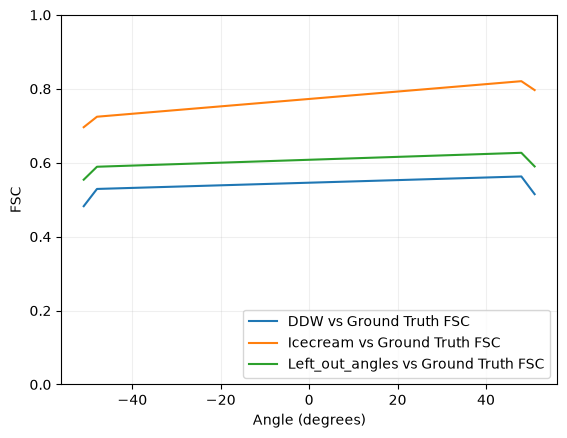

In [13]:
plt.figure()
plt.plot(angles, [fs_score[1][2][2] for fs_score in FC_scores], label="DDW vs Ground Truth FSC")
plt.plot(angles, [fs_score[1][3][2] for fs_score in FC_scores], label="Icecream vs Ground Truth FSC")
plt.plot(angles, [fs_score[1][1][2] for fs_score in FC_scores], label="Left_out_angles vs Ground Truth FSC")
plt.legend(loc='lower right')
plt.grid(alpha=0.2)
plt.ylim(0,1)
plt.xlabel("Angle (degrees)")
plt.ylabel("FSC")
plt.show()

In [14]:
### Fourier Shell Correlation (FSC) analysis

def FRC(f1, f2):
    """Fourier Ring Correlation between two rfft-convention slices (ky centred, kx from 0).
    Returns spatial frequency (cycles/pixel) and the FRC value per ring."""
    f1 = f1.detach().cpu().numpy()
    f2 = f2.detach().cpu().numpy()
    assert f1.shape == f2.shape, "Slices must have the same shape."
    ny, nx = f1.shape
    ky = np.arange(ny) - ny // 2
    kx = np.arange(nx)
    ring = np.round(np.sqrt(ky[:, None]**2 + kx[None, :]**2)).astype(int).ravel()

    n_rings = ny // 2                                    # up to Nyquist
    num = np.bincount(ring, (np.conj(f1) * f2).real.ravel())[:n_rings]
    d1  = np.bincount(ring, (np.abs(f1)**2).ravel())[:n_rings]
    d2  = np.bincount(ring, (np.abs(f2)**2).ravel())[:n_rings]

    return np.arange(n_rings) / ny, num / np.sqrt(d1 * d2 + 1e-20)

volume_names = ["Ground truth", "Left_out_angles", "Icecream", "DDW"]
volume_slices = [images_ground_truth, images_fbp, images_icecream, images_ddw]

pixel_size = 10.0
frc_results = {}   # frc_results[name][angle] = (freq, frc)

for name, slices in zip(volume_names[1:], volume_slices[1:]):
    frc_results[name] = {}
    for angle_index, angle in enumerate(angles):
        frc_results[name][angle] = FRC(images_ground_truth[angle_index], slices[angle_index])

In [54]:
def calculate_fsc(vol1, vol2, wedge_angles=None):
    """
    FSC between two 3D volumes (z, y, x), optionally restricted to an
    angular band of Fourier space (e.g. the 50-60 degree band between
    a +-50 and a +-60 tilt range).

    wedge_angles : (a_low, a_high) in degrees, or None for the full shell.
                    Keeps voxels with a_low < angle <= a_high, where angle
                    is measured from the in-plane axis towards kz.
    tilt_axis    : "y" or "x", the axis the specimen was tilted around.

    Returns:
    --------
    fsc_curve : numpy.ndarray
        1D array containing the FSC value for each spatial frequency shell.
    radii : numpy.ndarray
        1D array containing the corresponding shell radii in pixels.
    """
    assert vol1.shape == vol2.shape, "Volumes must have the same shape"

    # 1. Compute 3D Fast Fourier Transforms
    f1 = np.fft.fftn(vol1)
    f2 = np.fft.fftn(vol2)

    # Shift the zero-frequency component to the center of the spectrum
    f1_shifted = np.fft.fftshift(f1)
    f2_shifted = np.fft.fftshift(f2)

    # 2. Coordinate setup in Fourier space
    shape = vol1.shape
    cz, cy, cx = [dim // 2 for dim in shape]
    z, y, x = np.ogrid[-cz:shape[0]-cz, -cy:shape[1]-cy, -cx:shape[2]-cx] # same as [-cz:cz, ....]

    # Calculate distance (radius) of each voxel from the origin
    r_mesh = np.sqrt(x**2 + y**2 + z**2)

    # Create only a mesh between the angles of a wedge
    if wedge_angles is not None:
        a_low, a_high = wedge_angles
        a_low = np.radians(a_low)
        a_high = np.radians(a_high)

        # by taking the absolute values, each quadrant will be included
        z_relative = np.abs(z - cz)
        x_relative = np.abs(x - cx)
        angles = np.arctan2(z_relative, x_relative)
        angles = np.mod(angles, 2*np.pi)
        mask_wedge = (angles >= a_low) & (angles <= a_high)

    # Bin radial values into integer pixel shells up to the Nyquist limit
    max_radius = int(np.floor(min(shape) / 2))

    radii = np.arange(0, max_radius)
    fsc_curve = np.zeros(len(radii))

    # 3. Compute cross-correlation per shell
    for i, r in enumerate(radii):
        # Define mask for the current shell (thickness of 1 pixel)
        mask = (r_mesh >= r) & (r_mesh < r + 1)
        if wedge_angles is not None:
            mask = mask & mask_wedge

        # Extract Fourier coefficients within the shell
        f1_shell = f1_shifted[mask]
        f2_shell = f2_shifted[mask]

        if len(f1_shell) == 0:
            fsc_curve[i] = 0
            continue

        # FSC formula: Sum(V1 * conj(V2)) / sqrt(Sum(|V1|^2) * Sum(|V2|^2))
        numerator = np.sum(f1_shell * np.conj(f2_shell))
        denominator = np.sqrt(np.sum(np.abs(f1_shell)**2) * np.sum(np.abs(f2_shell)**2))

        if denominator == 0:
            fsc_curve[i] = 0
        else:
            # Take the real part as the imaginary terms cancel out statistically
            fsc_curve[i] = np.real(numerator / denominator)

    return fsc_curve, radii

angles = (48, 51)
# angles = None
fsc_rem_angles, r = calculate_fsc(box_ground_truth_data, box_fbp_truth_data, angles)
fsc_icecream, r = calculate_fsc(box_ground_truth_data, box_icecream_truth_data, angles)
fsc_ddw, r = calculate_fsc(box_ground_truth_data, box_ddw_truth_data, angles)

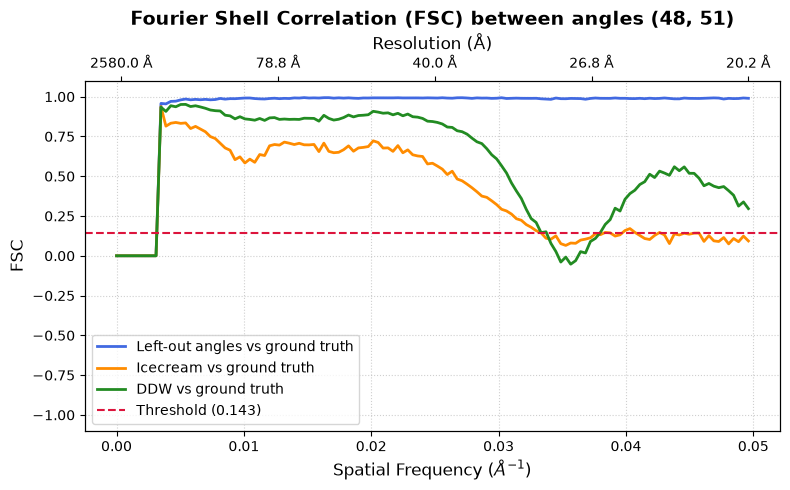

In [55]:
voxel_size = 10.0
box_size_px = len(fsc_rem_angles) * 2
spatial_frequencies = r / (box_size_px * voxel_size)

plt.figure(figsize=(8, 5))
plt.plot(
    spatial_frequencies,
    fsc_rem_angles,
    label="Left-out angles vs ground truth",
    color="royalblue",
    lw=2,
)
plt.plot(
    spatial_frequencies,
    fsc_icecream,
    label="Icecream vs ground truth",
    color="darkorange",
    lw=2,
)
plt.plot(
    spatial_frequencies,
    fsc_ddw,
    label="DDW vs ground truth",
    color="forestgreen",
    lw=2,
)

threshold = 0.143
plt.axhline(
    y=threshold,
    color="crimson",
    linestyle="--",
    label=f"Threshold ({threshold})",
)

plt.title(f"Fourier Shell Correlation (FSC) between angles {angles}", fontsize=14, fontweight="bold")
plt.xlabel("Spatial Frequency ($Å^{-1}$)", fontsize=12)
plt.ylabel("FSC", fontsize=12)
plt.ylim(-1.1, 1.1)
plt.grid(True, linestyle=":", alpha=0.6)

ax1 = plt.gca()
ax2 = ax1.twiny()
positive_frequencies = spatial_frequencies[spatial_frequencies > 0]
tick_freqs = np.linspace(positive_frequencies[0], positive_frequencies[-1], 5)
tick_resolutions = [f"{1 / frequency:.1f} Å" for frequency in tick_freqs]

ax2.set_xlim(ax1.get_xlim())
ax2.set_xticks(tick_freqs)
ax2.set_xticklabels(tick_resolutions)
ax2.set_xlabel("Resolution (Å)", fontsize=12)

ax1.legend(loc="lower left")
plt.tight_layout()
plt.show()


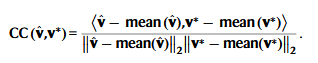

By definition, it holds that 0 ≤ CC  ≤ 1, and the higher the correlation between reconstruction and ground truth, the better. The correlation coefficient measures the reconstruction quality (both the denoising and the missing wedge reconstruction capabilities) of the methods.

In [17]:
### Correlation Coefficient

def CC(V_1, V_2):
    """"
    Takes two real space volumes and calculates the 
    correlation coefficient

    returns:
        CC (correlation coefficient)
    """
    V_1 = np.asarray(V_1, dtype=np.float64)   # float64 avoids precision loss in big sums
    V_2 = np.asarray(V_2, dtype=np.float64)
    assert V_1.shape == V_2.shape, "Volumes must have the same shape."

    V_1_diff = V_1 - V_1.mean()
    V_2_diff = V_2 - V_2.mean()

    upper = np.sum(V_1_diff * V_2_diff)                                    # inner product
    lower = np.sqrt(np.sum(V_1_diff**2)) * np.sqrt(np.sum(V_2_diff**2))    # product of L2 norms

    return upper / lower

# box_ground_truth_data
cc_measurements = [box_ddw_truth_data, box_icecream_truth_data, box_fbp_truth_data]
cc_names = ["DDW", "Icecream", "Removed_angles"]

for i, cc_measurement in enumerate(cc_measurements):
    print(f"For {cc_names[i]} compared to ground truth the CC is {CC(box_ground_truth_data, cc_measurement)}")

For DDW compared to ground truth the CC is 0.6276477629180076
For Icecream compared to ground truth the CC is 0.4940340924207242
For Removed_angles compared to ground truth the CC is 0.9743001686237096


In [18]:
np.max(np.asarray(ground_truth_data, dtype=np.float64))

np.float64(0.376220703125)

(-0.1, 0.1)

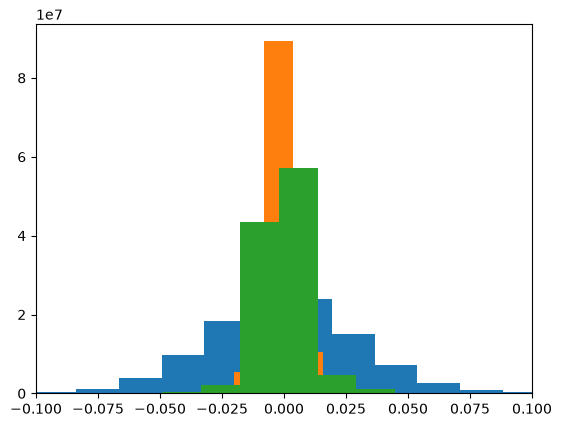

In [19]:
gt = np.asarray(ground_truth_data, dtype=np.float64)
it = np.asarray(icecream_truth_data, dtype=np.float64)
ddw = np.asarray(ddw_truth_data, dtype=np.float64)

plt.hist(gt.flatten() / np.max(gt), bins=100)
plt.hist(it.flatten() / np.max(it), bins=100)
plt.hist(ddw.flatten() / np.max(ddw), bins=100)
plt.xlim(-0.1, 0.1)